<a href="https://colab.research.google.com/github/somid05/ML-2026/blob/main/W3/labsheet2-Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <center>CITS5508 Lab sheet 2: Implementing a simple classification task</center>

This is an example notebook to help you implement the tasks required for this lab sheet.

We have provided some ideas to help you. Use the unit content and your thinking to create the several necessary steps.

You will develop Python code for a simple classification task in this lab sheet. Certify that the presentation of your Python notebook is good and that you used the Markdown cells well. Make sure you properly format your plots and results. For instance, all your diagrams/plots should have proper axis labels and titles to help the reader understand what you are plotting. Another example is the confusion matrix; not showing the class names makes the confusion matrix completely useless. Use the lab sheets to learn how to improve the presentation of your notebook, as you will need this in the assessments.

### Importing the libraries

In [ ]:
#You may need to add other libraries here depending on your code

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# to display plots in Jupyter notebook
%matplotlib inline

plt.rcParams['font.size'] = '12'

### 1. Loading the data

Load the data and create your training and test datasets.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Hint: Look at the function pd.read_csv()
file_path = '/content/drive/My Drive/Machine Learning/'
df_train = pd.read_csv(file_path + 'training.csv')
df_test = pd.read_csv(file_path + 'testing.csv')

### 2. Quick inspecting the data

Inspect what the columns are. Try the different options as discussed in lectures (e.g. head() and info() functions). Don't forget to use appropriate formatting in your output answers. What can you observe? Are there any issues with the data?

In [ ]:
column_headings = df_train.columns
#format your print, e.g.
#print('Column headings are: ',column_headings)

print('Column headings are: ', column_headings)


In [ ]:
info_train = df_train.info()
print(info_train)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   class                325 non-null    object 
 1   b1                   325 non-null    int64  
 2   b2                   325 non-null    int64  
 3   b3                   325 non-null    int64  
 4   b4                   325 non-null    int64  
 5   b5                   325 non-null    int64  
 6   b6                   325 non-null    int64  
 7   b7                   325 non-null    int64  
 8   b8                   325 non-null    int64  
 9   b9                   325 non-null    int64  
 10  pred_minus_obs_H_b1  325 non-null    float64
 11  pred_minus_obs_H_b2  325 non-null    float64
 12  pred_minus_obs_H_b3  325 non-null    float64
 13  pred_minus_obs_H_b4  325 non-null    float64
 14  pred_minus_obs_H_b5  325 non-null    float64
 15  pred_minus_obs_H_b6  325 non-null    flo

In [ ]:
info_test = df_test.info()
print(info_test)

### 3. Removing some columns from the dataset

We are going to drop all the columns *pred_minus_obs...*, i.e., we keep only the first 10 columns: the *class* column and the columns b1, b2, ..., b9. Don't forget to apply these changes to the training and test sets.

In [ ]:
#You need to create a code to remove the undesired columns from the training and testing sets. After that,
#inspect what your datasets look like. Do you have the correct data matrix structure (that is, rows represent the examples
#and columns represent the attributes?


#drop columns 10-27 from the training set
df_train.drop(df_train.columns[10:28], axis=1, inplace=True)

#drop columns 10-27 from the testing set
df_test.drop(df_test.columns[10:28], axis=1, inplace=True)

In [ ]:
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   325 non-null    object
 1   b1      325 non-null    int64 
 2   b2      325 non-null    int64 
 3   b3      325 non-null    int64 
 4   b4      325 non-null    int64 
 5   b5      325 non-null    int64 
 6   b6      325 non-null    int64 
 7   b7      325 non-null    int64 
 8   b8      325 non-null    int64 
 9   b9      325 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 25.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   198 non-null    object
 1   b1      198 non-null    int64 
 2   b2      198 non-null    int64 
 3   b3      198 non-null    int64 
 4   b4      198 non-null    int64 
 5   b5      198 non-null    int64 
 6   b6      198 no

### 4. Counting the number of instances in each class

According to the UCI Machine Learning website, this dataset has 4 class labels given in the first column of the csv file: Class: *s* ('Sugi' forest), *h* ('Hinoki' forest), *d* ('Mixed deciduous' forest), *o* ('Other' non-forest land). Write Python code to count instances/examples for each class label in your datasets. Are they imbalanced?

In [ ]:
#count the number of examples in the training set that belong to each class (that is, the number of examples with label 0 and the number of examples with label 1)
class_counts = df_train['class'].value_counts()
#change the classes to s=sugi forest, h=hinoki forest, d=mixed deciduous forest, o=other
class_counts.index = class_counts.index.map({'s': 'sugi forest',
                                             'h': 'hinoki forest',
                                             'd': 'mixed deciduous forest',
                                             'o': 'other'})
print(class_counts)



class
sugi forest               136
mixed deciduous forest    105
other                      46
hinoki forest              38
Name: count, dtype: int64


### 5. Doing some data visualisation

Use appropriate functions to display (visualise) the different features (attributes/columns). You can also incorporate class information. Do you observe any aspect of the data that should be addressed?

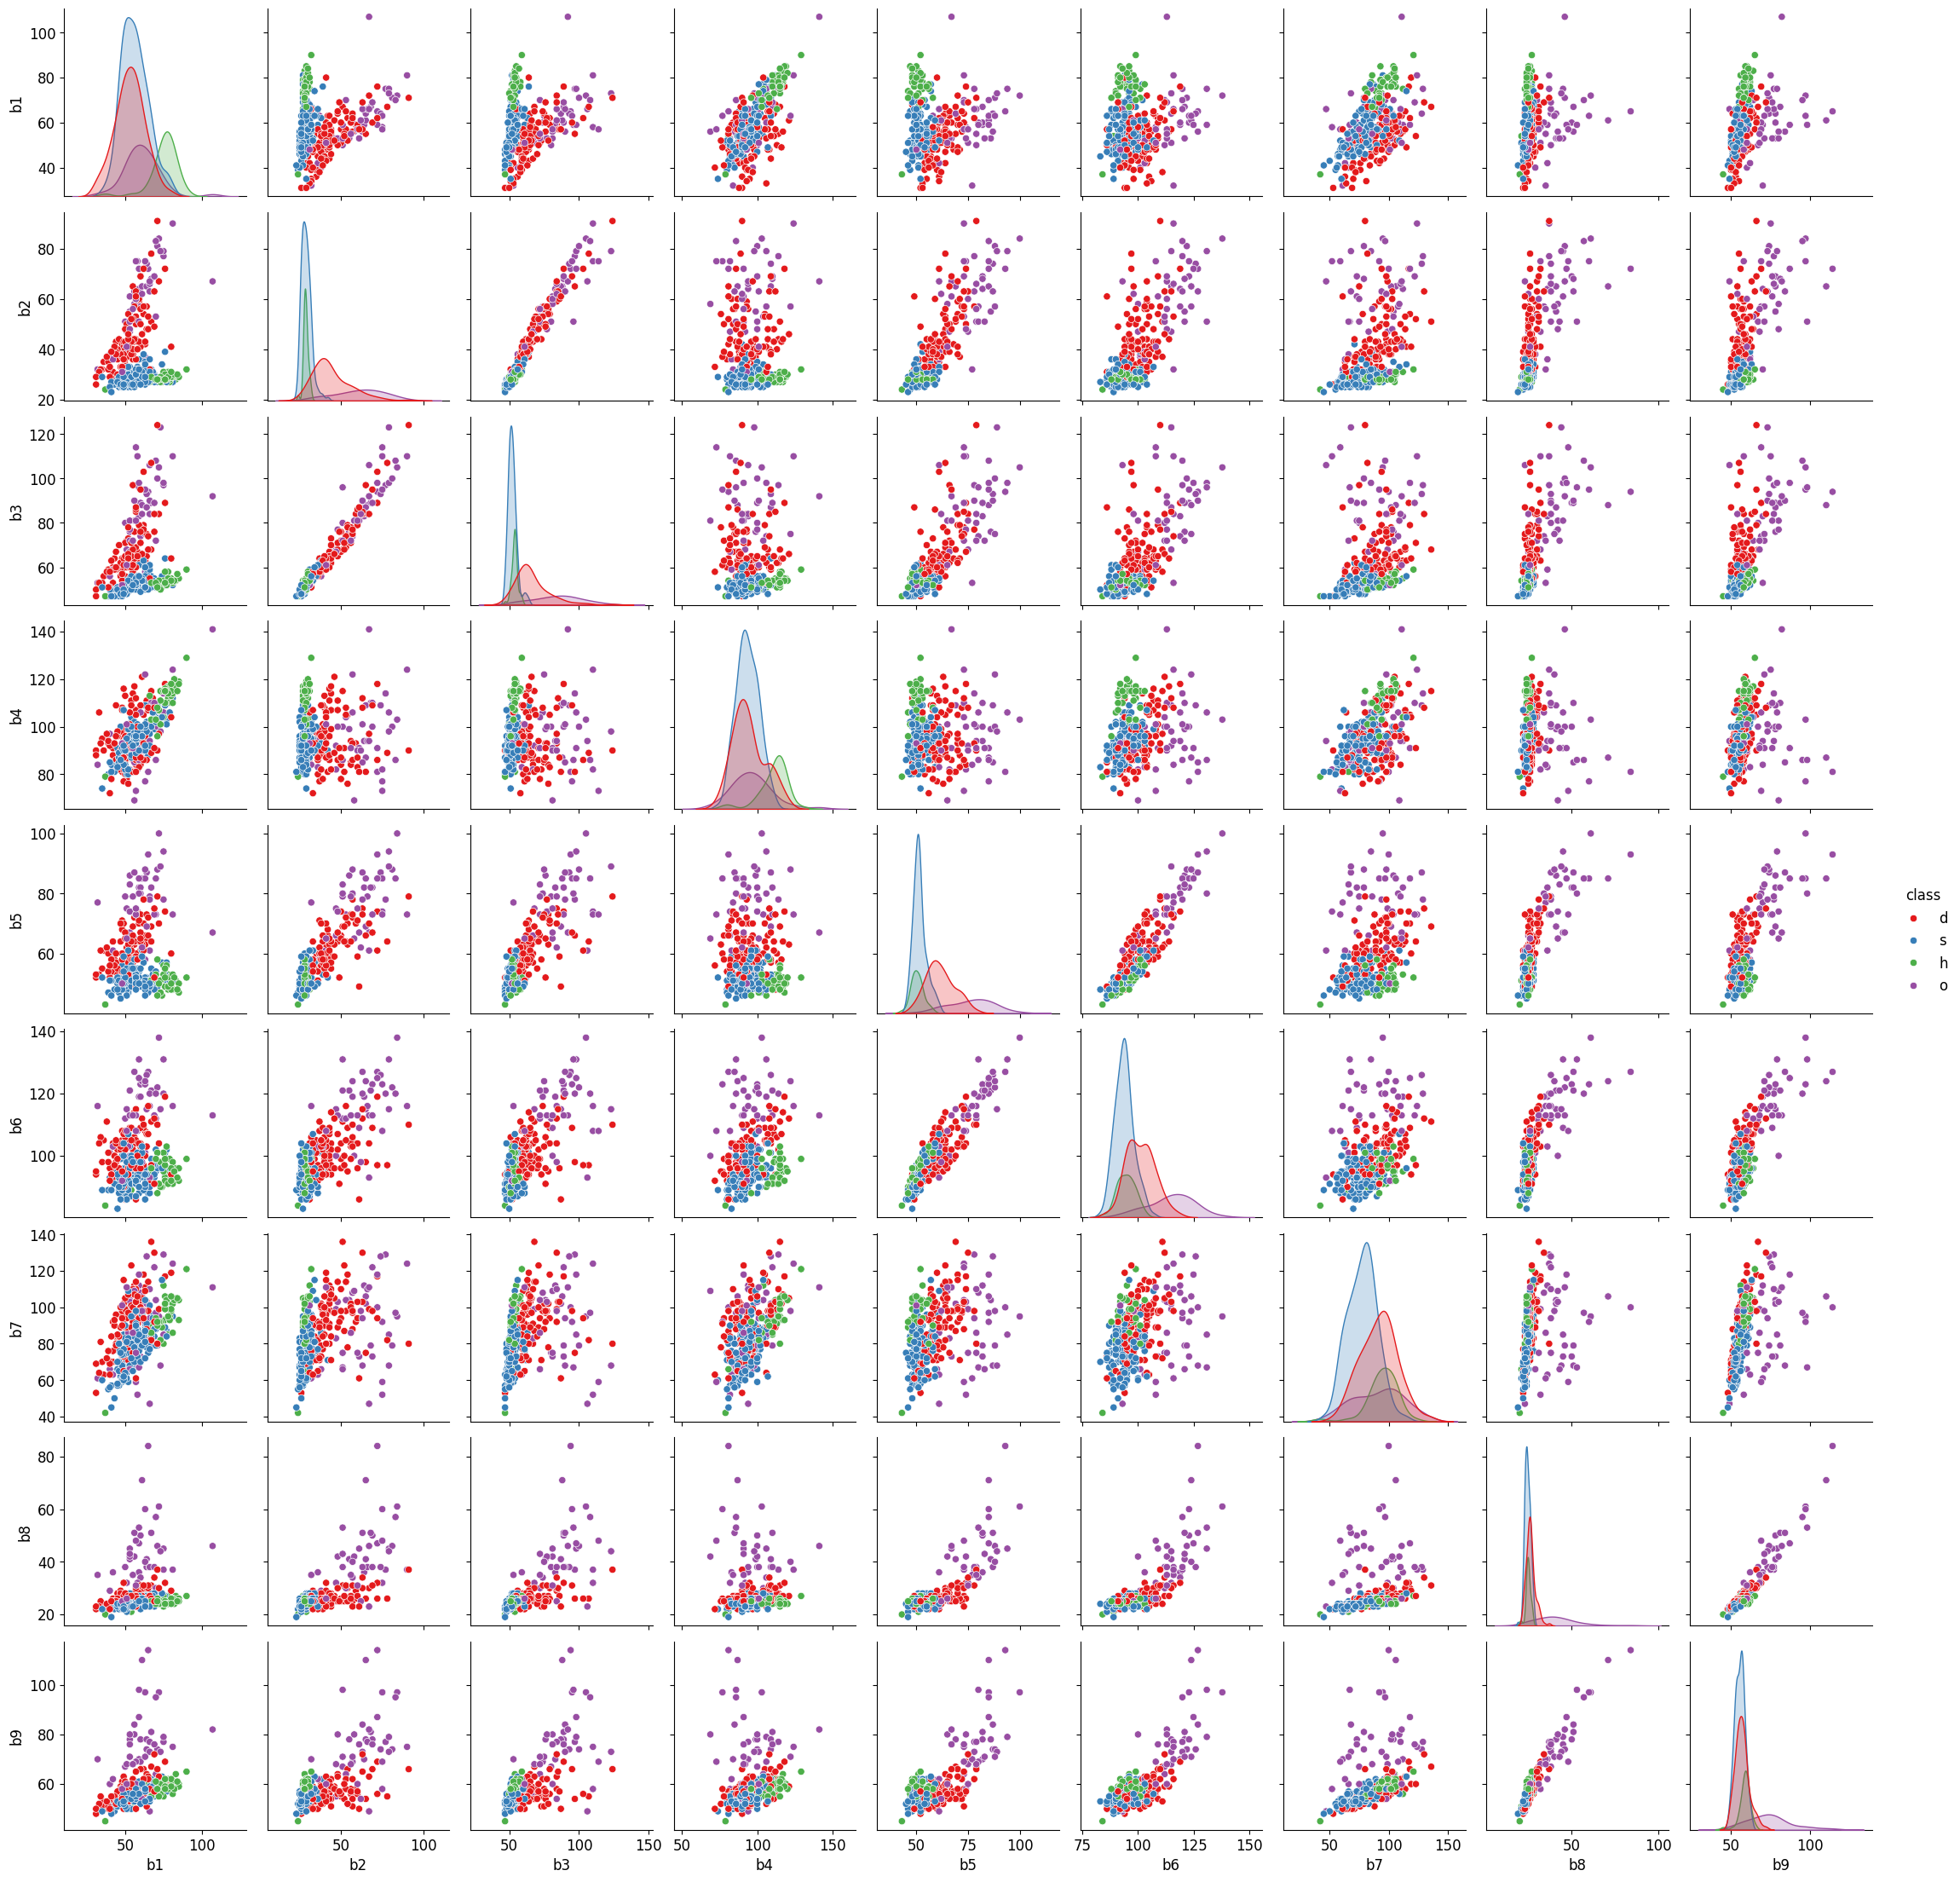

In [ ]:
#pairwise scatter plot of the attributes in the training set, use seaborn library
import seaborn as sns

#separate the classess with different colors in the pairwise scatter plot, use seaborn library
sns.pairplot(df_train, hue='class', palette='Set1')
plt.show()

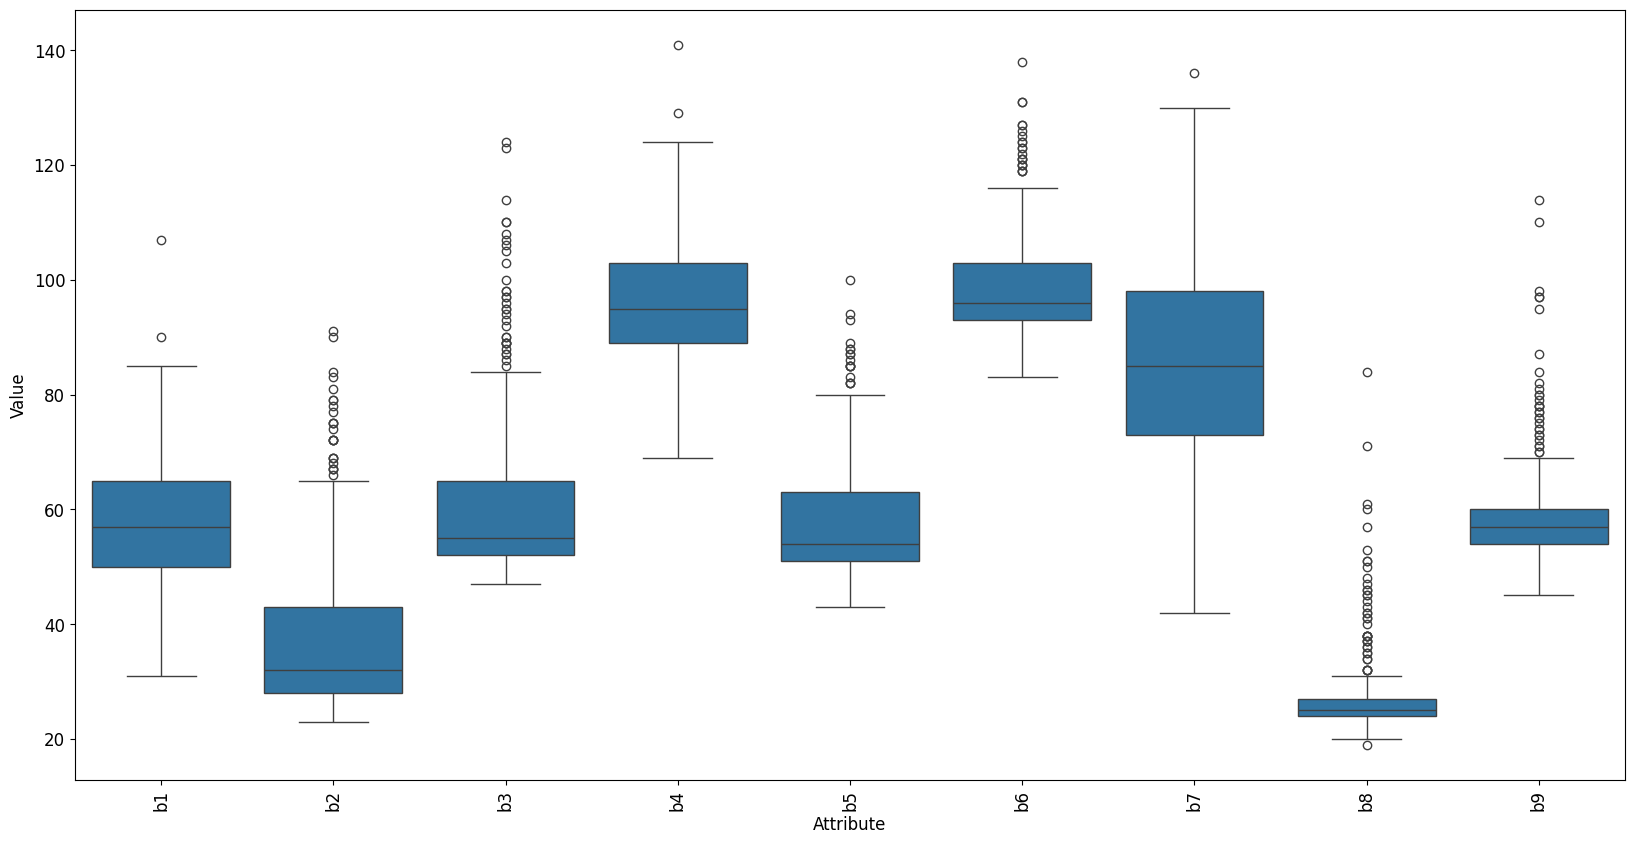

In [ ]:
#visualize the distribution of attributes using boxplot from df_train, use seaborn library
import seaborn as sns
dataset_melted = dataset.melt(var_name='Attribute', value_name='Value')
plt.figure(figsize=(20, 10))
sns.boxplot(x='Attribute', y='Value', data=dataset_melted)
plt.xticks(rotation=90)
plt.show()



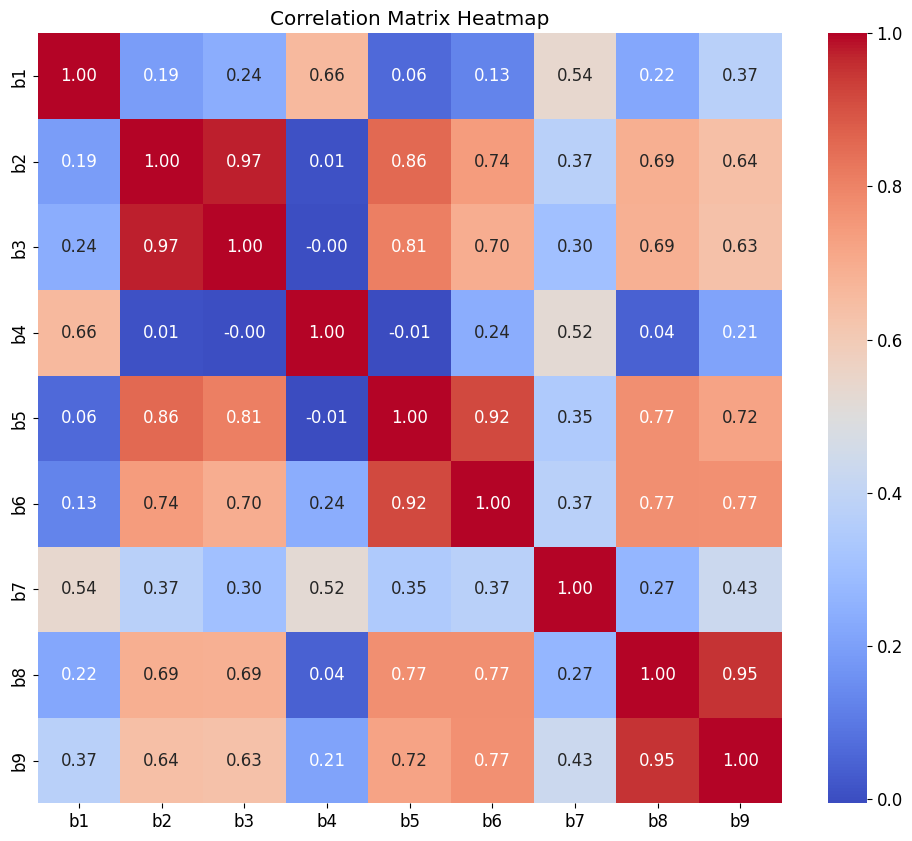

In [ ]:
#correlation matrix of the attributes in the training set, use seaborn library to visualize it as a heatmap
correlation_matrix = dataset.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

### 6. Preparing the data for a binary classification

We will do a multiclass classification on this dataset later. For now, we will start with a binary classification. Update your training and testing sets to contain only examples from two classes: "s" ("Sugi" forest) and  "d" ("Mixed deciduous" forest).

In [ ]:
#update training set to contain only class s & d
df_train_sd = df_train[df_train['class'].isin(['s', 'd'])]
df_train_sd.info()

#update testing set to contain only class s & d
df_test_sd = df_test[df_test['class'].isin(['s', 'd'])]
df_test_sd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 241 entries, 0 to 323
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   241 non-null    object
 1   b1      241 non-null    int64 
 2   b2      241 non-null    int64 
 3   b3      241 non-null    int64 
 4   b4      241 non-null    int64 
 5   b5      241 non-null    int64 
 6   b6      241 non-null    int64 
 7   b7      241 non-null    int64 
 8   b8      241 non-null    int64 
 9   b9      241 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 20.7+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 113 entries, 0 to 194
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   113 non-null    object
 1   b1      113 non-null    int64 
 2   b2      113 non-null    int64 
 3   b3      113 non-null    int64 
 4   b4      113 non-null    int64 
 5   b5      113 non-null    int64 
 6   b6      113 non-null    

### 7. Using the Logistic Regression

Use the **Logistic Regression Classifier** implemented in **sklearn.linear\_model** class to perform a binary classification on the updated datasets. Try also to implement your version of the Logistic Regression (do you arrive at similar results as the package?). Implementing your version is the best way to learn.

In [ ]:
#import sklearn library to perform classification using logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

#create a logistic regression model and fit it to the training data
X_train = df_train_sd.drop('class', axis=1)
y_train = df_train_sd['class']
X_test = df_test_sd.drop('class', axis=1)
y_test = df_test_sd['class']
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

#create scaler object and fit it to the training data, then transform the training data using the scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


#make predictions on the testing set
y_pred = model.predict(X_test)

#evaluate the performance of the model using classification report, confusion matrix, and accuracy score
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           d       0.98      1.00      0.99        54
           s       1.00      0.98      0.99        59

    accuracy                           0.99       113
   macro avg       0.99      0.99      0.99       113
weighted avg       0.99      0.99      0.99       113

[[54  0]
 [ 1 58]]
0.9911504424778761


In [ ]:
#create my own logistic regression model and fit it to the training data
class MyLogisticRegression:
    def __init__(self, learning_rate=0.01, max_iter=1000):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.max_iter):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_cls)


In [ ]:

my_model = MyLogisticRegression(learning_rate=0.01, max_iter=1000)
my_model.fit(X_train, y_train) #fit the model to the training data
y_pred_my_model = my_model.predict(X_test)
print(classification_report(y_test, y_pred_my_model))


TypeError: unsupported operand type(s) for -: 'float' and 'str'

### 8. Inspecting performance indicators

Write Python code to show results for:

- The accuracy values for the training set and the test set.
- The confusion matrix on the training and testing set.  
- The plot of precision versus recall for the training set.

Make sure you format the output properly.

In [ ]:
# ...

### *Optional, but may be covered in assessments.*

### 9. Plotting the estimated probabilities and decision boundary of the Logistic Regression model.

Consider two individual features in our dataset. We will use them to examine the estimated probabilities and decision boundary of the Logistic Regression model. You can choose which ones and/or experiment with different pairs of features. For each pair, you should create a new version of your training set using these two features only.

Also, to plot the Logistic Regression Classifier's estimated probabilities and decision boundary (as in Figure 4.23 of the textbook), considering these two individual features, you will need to create a Logistic Regression model for each feature. Hence, you are to provide two plots.

In [ ]:
# ...

Based on your plots, comment about:

- What threshold would you choose for classification based on the predicted probabilities?
- What is the impact of changing the threshold for performance indicators such as precision and recall?
- What can you say about the overlap between classes, and how does this impact classification performance?